In [1]:
# Importando bibliotecas

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import unicodedata

In [2]:
# Definindo algumas funções

def index_columns(df):
    df.columns = ['C{}'.format(i) for i in range(1,len(df.columns)+1)]
    return df

def padronizar_genero(texto):
    if pd.isna(texto):
        return pd.NA
    texto = str(texto).strip().lower()
    texto = unicodedata.normalize('NFKD', texto).encode('ascii', 'ignore').decode('utf-8')
    return genero_map.get(texto, 'OUTROS')


In [3]:
print(f"Importando os dados de todos os arquivos OMS: \n")

# Importacao de todos os arquivos CSV separando dados por ano

files = ['../data/raw/survey/survey_2016.csv', '../data/raw/survey/survey_2017.csv', '../data/raw/survey/survey_2018.csv', '../data/raw/survey/survey_2019.csv', '../data/raw/survey/survey_2020.csv']

dfs = []
for file in files:
    ano = file.split("_")[0][-4:]  # Extrai o ano do nome do arquivo
    df = pd.read_csv(file)
    df['ano'] = ano
    dfs.append(df)
df_total = pd.concat(dfs, ignore_index=True)
df_total.info()
df_total.head(2)

Importando os dados de todos os arquivos OMS: 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2739 entries, 0 to 2738
Data columns (total 17 columns):
 #   Column                                                                                                                                         Non-Null Count  Dtype  
---  ------                                                                                                                                         --------------  -----  
 0   A sua empresa oferece beneficios referentes a saude mental como parte dos beneficios de saude?                                                 2315 non-null   object 
 1   A sua empresa ja debateu saude mental formalmente (por exemplo, via um programa de concientizacao corporativo)?                                2315 non-null   object 
 2   A sua empresa oferece recursos para aprender mais sobre saude mental e alternativas para buscar ajuda?                                         2315 non-

,A sua empresa oferece beneficios referentes a saude mental como parte dos beneficios de saude?,"A sua empresa ja debateu saude mental formalmente (por exemplo, via um programa de concientizacao corporativo)?",A sua empresa oferece recursos para aprender mais sobre saude mental e alternativas para buscar ajuda?,A sua privacidade eh protegida se voce optar por um tratamento de saude mental oferecido pela sua empresa?,"Caso voce sinta a necessidade de solicitar uma licenca do trabalho devido a saude mental, quao facil ou dificil seria fazer essa solicitacao?",Voce se sentiria confortavel discutindo uma questao de saude mental com o seu chefe direto?,Voce se sentiria confortavel discutindo uma questao de saude mental com os seus pares?,O quao propenso voce estaria em dividir com amigos e familiares que voce possui uma doenca mental?,"Se voce revelou uma doenca mental para um cliente ou contato de negocio, como isso afetou voce e/ou o relacionamento?","Se voce revelou uma doenca mental para um para par ou funcionario, como isso afetou voce e/ou o relacionamento?",Idade,Genero,Qual pais voce reside?,Qual pais voce trabalha?,Voce ja foi diagnosticado com uma doenca mental?,Voce ja procurou tratamento profissional para uma doenca mental?,ano
0,Nao elegivel,Nao,Nao,Eu nao sei,Muito Facil,Sim,Talvez,Um pouco aberto,NaN,NaN,39.0,Masculino,United Kingdom,United Kingdom,Sim,Nao,2016
1,Nao,Sim,Sim,Sim,Facil,Sim,Talvez,Um pouco aberto,NaN,NaN,29.0,masculino,United States,United States,Sim,Sim,2016


In [4]:
print(f"Construindo um dicionario com o nome das colunas: \n")

keys = ['C{}'.format(i) for i in range(len(df_total.columns))]
columns_dic = pd.Series(df_total.columns,index=keys)
df_total.columns = keys
df_total.info()
df_total.head(2)

Construindo um dicionario com o nome das colunas: 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2739 entries, 0 to 2738
Data columns (total 17 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   C0      2315 non-null   object 
 1   C1      2315 non-null   object 
 2   C2      2315 non-null   object 
 3   C3      2315 non-null   object 
 4   C4      2315 non-null   object 
 5   C5      2315 non-null   object 
 6   C6      2315 non-null   object 
 7   C7      2739 non-null   object 
 8   C8      196 non-null    object 
 9   C9      424 non-null    object 
 10  C10     2739 non-null   float64
 11  C11     2719 non-null   object 
 12  C12     2739 non-null   object 
 13  C13     2739 non-null   object 
 14  C14     1927 non-null   object 
 15  C15     2739 non-null   object 
 16  C16     2739 non-null   object 
dtypes: float64(1), object(16)
memory usage: 363.9+ KB


,C0,C1,C2,C3,C4,C5,C6,C7,C8,C9,C10,C11,C12,C13,C14,C15,C16
0,Nao elegivel,Nao,Nao,Eu nao sei,Muito Facil,Sim,Talvez,Um pouco aberto,NaN,NaN,39.0,Masculino,United Kingdom,United Kingdom,Sim,Nao,2016
1,Nao,Sim,Sim,Sim,Facil,Sim,Talvez,Um pouco aberto,NaN,NaN,29.0,masculino,United States,United States,Sim,Sim,2016


In [5]:
print(f"Reduzindo o dataframe com as colunas de interesse: \n")

columns_a = ["C0","C1", "C11", "C10","C12", "C14","C15" ,"C16"]
df_total = df_total.drop(columns=[col for col in df_total.columns if col not in columns_a])
df_total.info()
df_total.head(2)

Reduzindo o dataframe com as colunas de interesse: 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2739 entries, 0 to 2738
Data columns (total 8 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   C0      2315 non-null   object 
 1   C1      2315 non-null   object 
 2   C10     2739 non-null   float64
 3   C11     2719 non-null   object 
 4   C12     2739 non-null   object 
 5   C14     1927 non-null   object 
 6   C15     2739 non-null   object 
 7   C16     2739 non-null   object 
dtypes: float64(1), object(7)
memory usage: 171.3+ KB


,C0,C1,C10,C11,C12,C14,C15,C16
0,Nao elegivel,Nao,39.0,Masculino,United Kingdom,Sim,Nao,2016
1,Nao,Sim,29.0,masculino,United States,Sim,Sim,2016


In [6]:
print(f"Definindo e filtrando dados de idade em um range válido: \n")

df_total['C10'] = df_total['C10'].astype(int)
df_total = df_total[(df_total['C10'] >= 10) & (df_total['C10'] <= 100)]
df_total.info()

Definindo e filtrando dados de idade em um range válido: 

<class 'pandas.core.frame.DataFrame'>
Index: 2735 entries, 0 to 2738
Data columns (total 8 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   C0      2312 non-null   object
 1   C1      2312 non-null   object
 2   C10     2735 non-null   int64 
 3   C11     2715 non-null   object
 4   C12     2735 non-null   object
 5   C14     1925 non-null   object
 6   C15     2735 non-null   object
 7   C16     2735 non-null   object
dtypes: int64(1), object(7)
memory usage: 192.3+ KB


In [7]:
print(f"Analisando os valores missing nas colunas: \n")

for col in df_total.columns:
    nulls = df_total[col].isna().sum()
    print('{}:{}'.format(col, nulls))

df_total.head()    

Analisando os valores missing nas colunas: 

C0:423
C1:423
C10:0
C11:20
C12:0
C14:810
C15:0
C16:0


,C0,C1,C10,C11,C12,C14,C15,C16
0,Nao elegivel,Nao,39,Masculino,United Kingdom,Sim,Nao,2016
1,Nao,Sim,29,masculino,United States,Sim,Sim,2016
2,Nao,Nao,38,Masculino,United Kingdom,Nao,Sim,2016
3,NaN,NaN,43,masculino,United Kingdom,Sim,Sim,2016
4,Sim,Nao,43,Feminino,United States,Sim,Sim,2016


Plotando análise de dados missing para melhor visualização: 



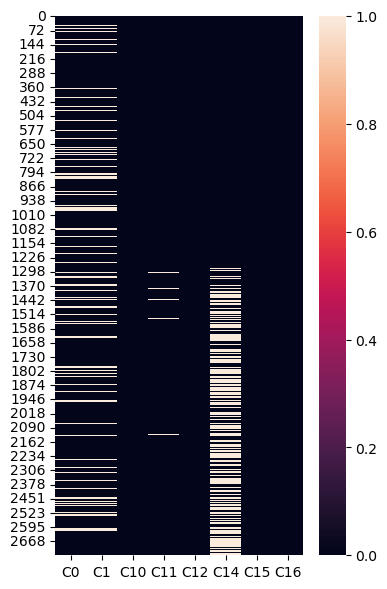

In [8]:
print(f"Plotando análise de dados missing para melhor visualização: \n")


plt.figure(figsize=(4,7))
sns.heatmap(df_total.isna())
plt.show()

In [9]:
print(f"Preencher valores ausentes com a moda (valor mais frequente) em colunas categóricas: \n")
colunas_para_preencher = ['C0','C1', 'C11', 'C14']

for col in colunas_para_preencher:
    if col in df_total.columns:
        moda = df_total[col].mode(dropna=True)
        if not moda.empty:
            df_total[col] = df_total[col].fillna(moda[0])
df_total.info()        
df_total.head(2)

Preencher valores ausentes com a moda (valor mais frequente) em colunas categóricas: 

<class 'pandas.core.frame.DataFrame'>
Index: 2735 entries, 0 to 2738
Data columns (total 8 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   C0      2735 non-null   object
 1   C1      2735 non-null   object
 2   C10     2735 non-null   int64 
 3   C11     2735 non-null   object
 4   C12     2735 non-null   object
 5   C14     2735 non-null   object
 6   C15     2735 non-null   object
 7   C16     2735 non-null   object
dtypes: int64(1), object(7)
memory usage: 192.3+ KB


,C0,C1,C10,C11,C12,C14,C15,C16
0,Nao elegivel,Nao,39,Masculino,United Kingdom,Sim,Nao,2016
1,Nao,Sim,29,masculino,United States,Sim,Sim,2016


In [10]:
print(f"Mapeando e agrupando dados por genero: \n")

generos_femininos = [
    'feminino', 'f', 'cisgenero feminino', 'mulher', 'fem', 'femininu', 'femenino',
    'feminino, ela/dela', 'me identifico como mulher', 'me identifico como feminina',
    'registrada no nascimento como feminino', 'meu sexo e feminino', 'cisgenero mulher',
    'feminino/mulher'
]
generos_masculinos = [
    'masculino', 'm', 'cisgenero masculino', 'homem', 'mascolino', 'masculino.', 
    'masculino (ei estamos em ti, do que vc esta falando)', 'maskulino', 
    'ostensivamente masculino', 'vamos manter simples e dizer masculino', 
    'majoritariamente masculino', 'sexo e masculino', 'm|', 'eu sou um homem!'
]
generos_outros = [
    'nao binario', 'nao-binario', 'genero fluido', 'fluido', 
    'fluidez de genero (nascida feminino)', 'bi-genero', 'sem genero', 'queer', 
    'transgenero', 'transgenero feminina', 'androgeno', 'nao e da sua conta', 
    'outros', 'outro', 'cara', 'humano', 'unicornio', 'contextual', 'em duvida', 
    'masculino (or feminino, ou ambos)', '\\----', '90% masculino, 10% feminino'
]

genero_map = {}

for g in generos_femininos:
    genero_map[g] = 'FEMININO'

for g in generos_masculinos:
    genero_map[g] = 'MASCULINO'

for g in generos_outros:
    genero_map[g] = 'OUTROS'

df_total['C11'] = df_total['C11'].apply(padronizar_genero)
df_total.head()

Mapeando e agrupando dados por genero: 



,C0,C1,C10,C11,C12,C14,C15,C16
0,Nao elegivel,Nao,39,MASCULINO,United Kingdom,Sim,Nao,2016
1,Nao,Sim,29,MASCULINO,United States,Sim,Sim,2016
2,Nao,Nao,38,MASCULINO,United Kingdom,Nao,Sim,2016
3,Sim,Nao,43,MASCULINO,United Kingdom,Sim,Sim,2016
4,Sim,Nao,43,FEMININO,United States,Sim,Sim,2016


Plotando dados normalizados para comparação: 



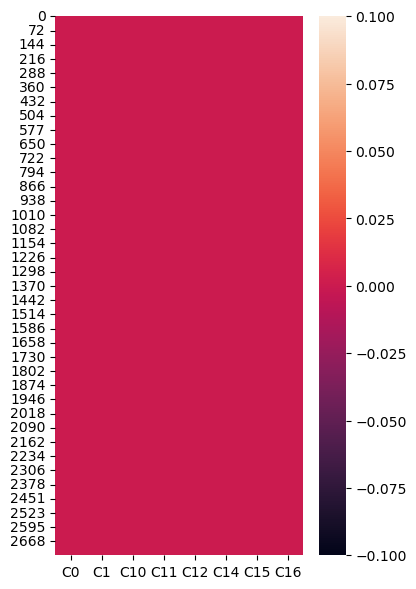

In [11]:
print(f"Plotando dados normalizados para comparação: \n")

plt.figure(figsize=(4,7))
sns.heatmap(df_total.isna())
plt.show()

In [12]:
print(f"Importando e analisando o arquivo de dados do PIB (Fase 01): \n")

df_file_pib = pd.read_csv('../data/processed/countries_gdp.csv')
df_file_pib.head(2)

Importando e analisando o arquivo de dados do PIB (Fase 01): 



,codigo,name,population,capital,continent,area,1960,1961,1962,1963,...,2012,2013,2014,2015,2016,2017,2018,2019,2020,2021
0,AND,Andorra,77006,Andorra la Vella,Europe,468.0,NaN,NaN,NaN,NaN,...,3.188809e+09,3.193704e+09,3.271808e+09,2.789870e+09,2.896679e+09,3.000181e+09,3.218316e+09,3.155065e+09,2.891022e+09,3.330282e+09
1,ARE,United Arab Emirates,9630959,Abu Dhabi,Asia,82880.0,NaN,NaN,NaN,NaN,...,3.846101e+11,4.002185e+11,4.141054e+11,3.702755e+11,3.692553e+11,3.905168e+11,4.270494e+11,4.179897e+11,3.494730e+11,4.150216e+11


In [13]:
print(f"Reduzindo o dataframe com as colunas de interesse: \n")

df_file_pib = df_file_pib[['name', '2016']]
df_file_pib.info()

Reduzindo o dataframe com as colunas de interesse: 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 188 entries, 0 to 187
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   name    188 non-null    object 
 1   2016    184 non-null    float64
dtypes: float64(1), object(1)
memory usage: 3.1+ KB


In [14]:
print(f"Preenchendo valores ausentes com a mediana : \n")
df_file_pib['2016'] = df_file_pib['2016'].fillna(df_file_pib['2016'].mean())
df_file_pib.info()


Preenchendo valores ausentes com a mediana : 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 188 entries, 0 to 187
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   name    188 non-null    object 
 1   2016    188 non-null    float64
dtypes: float64(1), object(1)
memory usage: 3.1+ KB


In [15]:
print(f"Cruzando dados dos dataframes da OMS e PIB: \n")

database_full = pd.merge(df_total, df_file_pib, left_on='C12', right_on='name', how='left')
database_full.head()


Cruzando dados dos dataframes da OMS e PIB: 



,C0,C1,C10,C11,C12,C14,C15,C16,name,2016
0,Nao elegivel,Nao,39,MASCULINO,United Kingdom,Sim,Nao,2016,United Kingdom,2.699660e+12
1,Nao,Sim,29,MASCULINO,United States,Sim,Sim,2016,United States,1.869511e+13
2,Nao,Nao,38,MASCULINO,United Kingdom,Nao,Sim,2016,United Kingdom,2.699660e+12
3,Sim,Nao,43,MASCULINO,United Kingdom,Sim,Sim,2016,United Kingdom,2.699660e+12
4,Sim,Nao,43,FEMININO,United States,Sim,Sim,2016,United States,1.869511e+13


In [16]:
print(f"Imprimindo índice e nome das colunas para consulta: \n")
columns_dic

Imprimindo índice e nome das colunas para consulta: 



C0     A sua empresa oferece beneficios referentes a ...
C1     A sua empresa ja debateu saude mental formalme...
C2     A sua empresa oferece recursos para aprender m...
C3     A sua privacidade eh protegida se voce optar p...
C4     Caso voce sinta a necessidade de solicitar uma...
C5     Voce se sentiria confortavel discutindo uma qu...
C6     Voce se sentiria confortavel discutindo uma qu...
C7     O quao propenso voce estaria em dividir com am...
C8     Se voce revelou uma doenca mental para um clie...
C9     Se voce revelou uma doenca mental para um para...
C10                                                Idade
C11                                               Genero
C12                               Qual pais voce reside?
C13                             Qual pais voce trabalha?
C14     Voce ja foi diagnosticado com uma doenca mental?
C15    Voce ja procurou tratamento profissional para ...
C16                                                  ano
dtype: object

In [17]:
print(f"RESPONDENDO PERGUNTAS")

RESPONDENDO PERGUNTAS


In [18]:
print(f"Renomeando colunas de forma objetiva: \n")
database_full = database_full.rename(columns={ 
    'C0': 'Beneficio?',
    'C10': 'Idade',
    'C11': 'Genero',
    'C14': 'Diagnostico?',
    'C15': 'Tratamento?',
    'C16': 'Ano'
})
database_full.head(2)

Renomeando colunas de forma objetiva: 



,Beneficio?,C1,Idade,Genero,C12,Diagnostico?,Tratamento?,Ano,name,2016
0,Nao elegivel,Nao,39,MASCULINO,United Kingdom,Sim,Nao,2016,United Kingdom,2.699660e+12
1,Nao,Sim,29,MASCULINO,United States,Sim,Sim,2016,United States,1.869511e+13


In [19]:
# 1. Existe uma diferença significativa de saúde mental entre os gêneros de colaboradores ao longo do tempo?

diagnostico_por_genero = database_full.copy()

print(f"Agrupamento de diagnostico por genero ao longo dos anos:")

diagnostico_por_genero = diagnostico_por_genero.groupby(['Ano' , 'Genero']).size().reset_index(name='Quantidade')

diagnostico_por_genero


Agrupamento de diagnostico por genero ao longo dos anos:


,Ano,Genero,Quantidade
0,2016,FEMININO,326
1,2016,MASCULINO,916
2,2016,OUTROS,30
3,2017,FEMININO,206
4,2017,MASCULINO,445
5,2017,OUTROS,18
6,2018,FEMININO,114
7,2018,MASCULINO,233
8,2018,OUTROS,19
9,2019,FEMININO,84


Plotando resultados do agrupamento: 


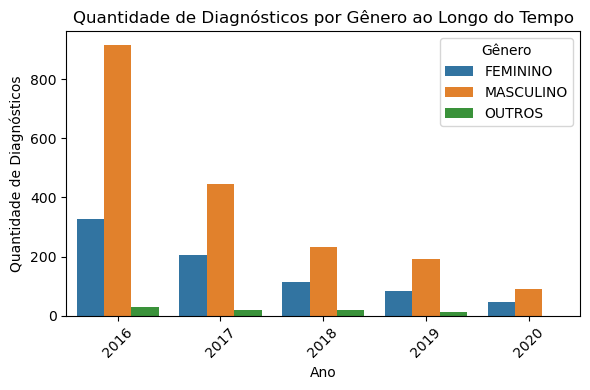

In [20]:
print(f"Plotando resultados do agrupamento: ")

plt.figure(figsize=(6,4))
sns.barplot(data=diagnostico_por_genero, x='Ano', y='Quantidade', hue='Genero')
plt.title('Quantidade de Diagnósticos por Gênero ao Longo do Tempo')
plt.xlabel('Ano')
plt.ylabel('Quantidade de Diagnósticos')
plt.legend(title='Gênero')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [21]:
# 2. Existe uma diferença significativa de quem busca tratamento entre os gêneros de colaboradores ao longo do tempo? Objetivo: Comparar proporção de quem busca tratamento por gênero, ao longo dos anos.

print(f"Proporção de tratamento entre generos ao longo dos anos:")

db_tratamento_genero = database_full.copy()

total_respostas_genero = db_tratamento_genero.groupby(['Ano', 'Genero']).size().reset_index(name='Total')
tratamento_sim_genero = db_tratamento_genero[db_tratamento_genero['Tratamento?'] == 'Sim'].groupby(['Ano', 'Genero']).size().reset_index(name='Qtd SIM Tratamento')

proporcao_tratamento_por_genero = pd.merge(total_respostas_genero, tratamento_sim_genero, on=['Ano', 'Genero'], how='left')
proporcao_tratamento_por_genero['Proporcao %'] = (proporcao_tratamento_por_genero['Qtd SIM Tratamento'] / proporcao_tratamento_por_genero['Total'] * 100).round(2)
proporcao_tratamento_por_genero



Proporção de tratamento entre generos ao longo dos anos:


,Ano,Genero,Total,Qtd SIM Tratamento,Proporcao %
0,2016,FEMININO,326,248,76.07
1,2016,MASCULINO,916,496,54.15
2,2016,OUTROS,30,26,86.67
3,2017,FEMININO,206,156,75.73
4,2017,MASCULINO,445,256,57.53
5,2017,OUTROS,18,14,77.78
6,2018,FEMININO,114,88,77.19
7,2018,MASCULINO,233,138,59.23
8,2018,OUTROS,19,14,73.68
9,2019,FEMININO,84,66,78.57


Plotando resultados do agrupamento: 


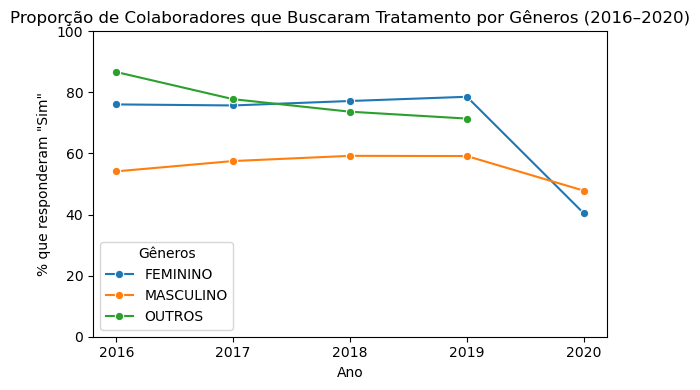

In [22]:
print(f"Plotando resultados do agrupamento: ")

plt.figure(figsize=(6, 4))
sns.lineplot(
    data=proporcao_tratamento_por_genero,
    x='Ano',
    y='Proporcao %',
    hue='Genero',
    marker='o'
)

plt.title('Proporção de Colaboradores que Buscaram Tratamento por Gêneros (2016–2020)')
plt.xlabel('Ano')
plt.ylabel('% que responderam "Sim"')
plt.ylim(0, 100)
plt.legend(title='Gêneros')
plt.tight_layout()
plt.show()

In [23]:
# 3. Existe uma diferença significativa de saúde mental entre as idades dos colaboradores ao longo do tempo em que a pesquisa foi realizada?

print(f"Criando faixa-etária de idades por agrupamento: ")

faixa_etaria = database_full.copy()

bins = [10, 20, 30, 40, 50, 60, 100]
faixas_idade = ['10-19', '20-29', '30-39', '40-49', '50-59', '60+']

faixa_etaria['Faixa Etaria'] = pd.cut(database_full['Idade'], bins=bins, labels=faixas_idade, right=False)

faixa_etaria.head(2)

Criando faixa-etária de idades por agrupamento: 


,Beneficio?,C1,Idade,Genero,C12,Diagnostico?,Tratamento?,Ano,name,2016,Faixa Etaria
0,Nao elegivel,Nao,39,MASCULINO,United Kingdom,Sim,Nao,2016,United Kingdom,2.699660e+12,30-39
1,Nao,Sim,29,MASCULINO,United States,Sim,Sim,2016,United States,1.869511e+13,20-29


In [24]:
print(f"Agrupamento de diagnostico por genero ao longo dos anos:")


total_respostas_faixa_etaria = faixa_etaria.groupby(['Ano', 'Faixa Etaria']).size().reset_index(name='Total')

diagnostico_faixa_etaria = faixa_etaria[faixa_etaria['Diagnostico?'] == 'Sim'].groupby(['Ano', 'Faixa Etaria']).size().reset_index(name='Qtd SIM Diagnostico')

proporcao_diagnostico_idade= pd.merge(total_respostas_faixa_etaria,diagnostico_faixa_etaria, on=['Ano', 'Faixa Etaria'], how='left')
proporcao_diagnostico_idade['Qtd SIM Diagnostico'] = proporcao_diagnostico_idade['Qtd SIM Diagnostico'].fillna(0)


# Calcular proporção
proporcao_diagnostico_idade['Proporcao %'] = ((proporcao_diagnostico_idade['Qtd SIM Diagnostico'] / proporcao_diagnostico_idade['Total']) * 100).round(2)
proporcao_diagnostico_idade.head(2)

Agrupamento de diagnostico por genero ao longo dos anos:


/var/folders/wj/_vm5m8g909gbgb5kst1b84900000gn/T/ipykernel_60422/1891509189.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  total_respostas_faixa_etaria = faixa_etaria.groupby(['Ano', 'Faixa Etaria']).size().reset_index(name='Total')
/var/folders/wj/_vm5m8g909gbgb5kst1b84900000gn/T/ipykernel_60422/1891509189.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  diagnostico_faixa_etaria = faixa_etaria[faixa_etaria['Diagnostico?'] == 'Sim'].groupby(['Ano', 'Faixa Etaria']).size().reset_index(name='Qtd SIM Diagnostico')


,Ano,Faixa Etaria,Total,Qtd SIM Diagnostico,Proporcao %
0,2016,10-19,6,1,16.67
1,2016,20-29,389,192,49.36


Plotando resultados do agrupamento: 


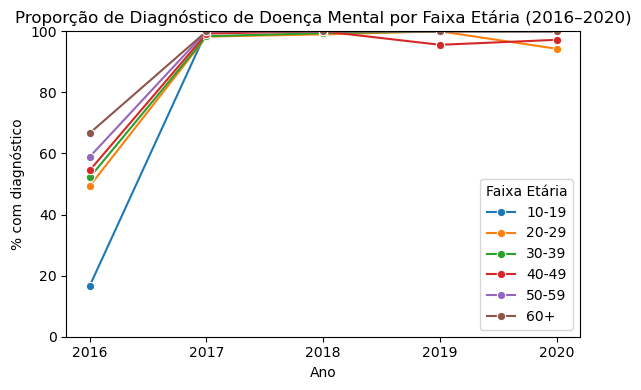

In [25]:
print(f"Plotando resultados do agrupamento: ")

plt.figure(figsize=(6, 4))
sns.lineplot(
    data=proporcao_diagnostico_idade,
    x='Ano',
    y='Proporcao %',
    hue='Faixa Etaria',
    marker='o'
)

plt.title('Proporção de Diagnóstico de Doença Mental por Faixa Etária (2016–2020)')
plt.xlabel('Ano')
plt.ylabel('% com diagnóstico')
plt.ylim(0, 100)
plt.legend(title='Faixa Etária')
plt.tight_layout()
plt.show()


In [26]:
#4. Existe uma diferença significativa de quem busca tratamento entre as idades dos colaboradores ao longo do tempo em que a pesquisa foi realizada?

print(f"Criando faixa-etária de idades por tratamento: ")

tratamento_por_ano = faixa_etaria[faixa_etaria['Tratamento?'] == 'Sim'].groupby(['Ano', 'Faixa Etaria']).size().reset_index(name='Qtd SIM Tratamento')
tratamento_por_ano['Qtd SIM Tratamento'] = tratamento_por_ano['Qtd SIM Tratamento'].fillna(0)

tratamento_por_ano['Proporcao %'] = (tratamento_por_ano['Qtd SIM Tratamento'] / total_respostas_faixa_etaria['Total'] * 100).round(2)
tratamento_por_ano.head(2)

Criando faixa-etária de idades por tratamento: 


/var/folders/wj/_vm5m8g909gbgb5kst1b84900000gn/T/ipykernel_60422/1385187971.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  tratamento_por_ano = faixa_etaria[faixa_etaria['Tratamento?'] == 'Sim'].groupby(['Ano', 'Faixa Etaria']).size().reset_index(name='Qtd SIM Tratamento')


,Ano,Faixa Etaria,Qtd SIM Tratamento,Proporcao %
0,2016,10-19,1,16.67
1,2016,20-29,230,59.13


Plotando resultados do agrupamento: 


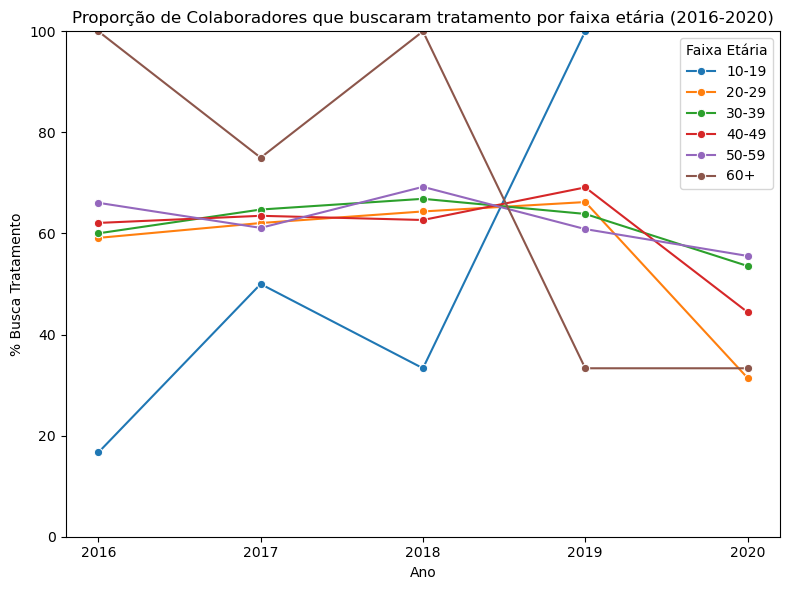

In [27]:
print(f"Plotando resultados do agrupamento: ")

plt.figure(figsize=(8, 6))
sns.lineplot(
    data=tratamento_por_ano,
    x='Ano',
    y='Proporcao %',
    hue='Faixa Etaria',
    marker='o'
)

plt.title('Proporção de Colaboradores que buscaram tratamento por faixa etária (2016-2020)')
plt.xlabel('Ano')
plt.ylabel('% Busca Tratamento')
plt.ylim(0, 100)
plt.legend(title='Faixa Etária')
plt.tight_layout()
plt.show()


In [28]:
# 5. Os funcionários de empresas que possuem benefícios de saúde para tratamento de saúde mental buscam mais tratamento?

db_beneficios_saude = database_full.copy()

beneficio_total = db_beneficios_saude.groupby('Beneficio?').size().reset_index(name='Total Respostas Beneficio')

beneficio_saude_sim = db_beneficios_saude[db_beneficios_saude['Tratamento?'] == 'Sim'].groupby(['Beneficio?']).size().reset_index(name='Qtd Sim Tratamento')
beneficio_total
beneficio_saude = pd.merge(beneficio_saude_sim, beneficio_total, on=['Beneficio?'], how='left')


beneficio_saude['Proporcao %'] = ((beneficio_saude['Qtd Sim Tratamento'] / beneficio_saude['Total Respostas Beneficio']) * 100).round(2)
beneficio_saude

,Beneficio?,Qtd Sim Tratamento,Total Respostas Beneficio,Proporcao %
0,Eu nao sei,291,623,46.71
1,Nao,158,295,53.56
2,Nao elegivel,39,66,59.09
3,Nao elegivel - NA,37,54,68.52
4,Sim,1163,1697,68.53


Plotando resultados do agrupamento: 


/var/folders/wj/_vm5m8g909gbgb5kst1b84900000gn/T/ipykernel_60422/1454050288.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=beneficio_saude, x='Beneficio?', y='Proporcao %', palette='Set2')


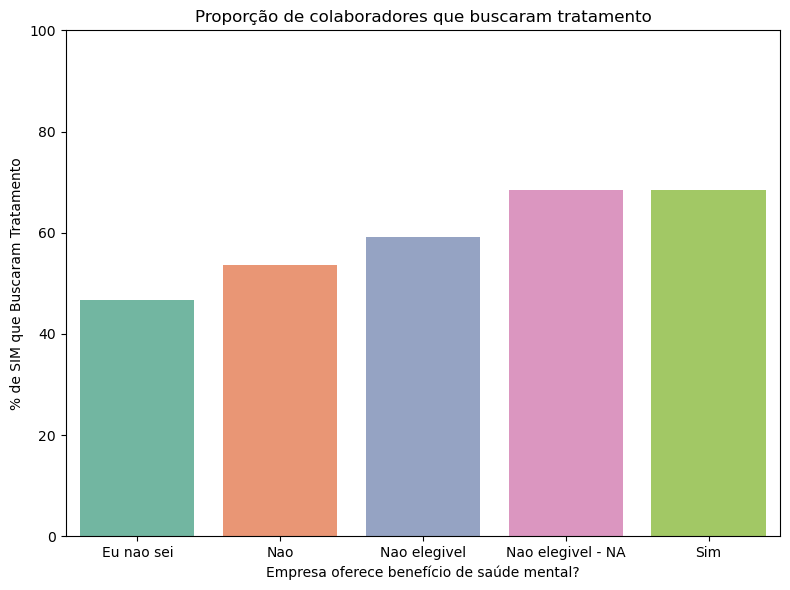

In [29]:
print(f"Plotando resultados do agrupamento: ")

plt.figure(figsize=(8, 6))
sns.barplot(data=beneficio_saude, x='Beneficio?', y='Proporcao %', palette='Set2')

plt.title('Proporção de colaboradores que buscaram tratamento')
plt.xlabel('Empresa oferece benefício de saúde mental?')
plt.ylabel('% de SIM que Buscaram Tratamento')
plt.ylim(0, 100)
plt.tight_layout()
plt.show()

In [30]:
# 6. Existe uma diferença significativa de saúde mental entre países mais ricos (com um PIB elevado) no ano de 2016? 

db_pib_saude =  database_full.copy()

media_pib = db_pib_saude['2016'].mean()

db_pib_saude['Pais Rico?'] = db_pib_saude['2016'] > media_pib

proporcao_diagnostico_pib = db_pib_saude.groupby('Pais Rico?')['Diagnostico?'].apply(lambda x: (x =='Sim').mean() * 100).reset_index(name='Proporcao %').round(2)
proporcao_diagnostico_pib.head(2)


,Pais Rico?,Proporcao %
0,False,68.90
1,True,80.52


Plotando resultados do agrupamento: 


/var/folders/wj/_vm5m8g909gbgb5kst1b84900000gn/T/ipykernel_60422/255103132.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=proporcao_diagnostico_pib, x='Pais Rico?', y='Proporcao %', palette='Set2')


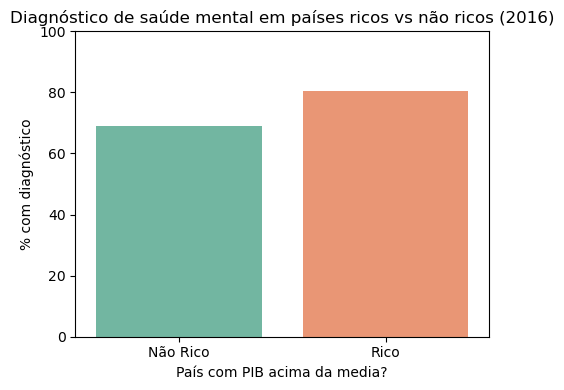

In [31]:
print(f"Plotando resultados do agrupamento: ")

plt.figure(figsize=(5, 4))
sns.barplot(data=proporcao_diagnostico_pib, x='Pais Rico?', y='Proporcao %', palette='Set2')

plt.title('Diagnóstico de saúde mental em países ricos vs não ricos (2016)')
plt.xlabel('País com PIB acima da media?')
plt.ylabel('% com diagnóstico')
plt.xticks([0, 1], ['Não Rico', 'Rico'])
plt.ylim(0, 100)
plt.tight_layout()
plt.show()
